# Part 1 — Time-Series Modeling for Washington

This notebook reproduces the **modeling/smoothing part** of the paper for Washington State.

The purpose here is not yet to forecast unseen future cases. Instead, I apply several time-series methods to the historical cumulative case series and compare how closely their fitted values represent the observed data.

The methods used are:

- 10-day Simple Moving Average (SMA)
- 30-day Simple Moving Average (SMA)
- 30-day Exponentially Weighted Moving Average (EWMA)
- Additive Holt-Winters exponential smoothing

I then compare the methods using **MSE and RMSE**, where a smaller value means the fitted series is closer to the actual observations.


## 1. Import libraries and load the prepared Washington dataset

I import all libraries required for this notebook in one place and load the CSV created in the data-extraction notebook.

This file already contains one daily cumulative confirmed-case value for Washington, so no county aggregation is needed here.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

path = "./washington_covid_confirmed.csv"

washington_df = pd.read_csv(path)

print(washington_df.shape)
washington_df.head()


(1104, 2)


,Date,ConfirmedCases
0,2020-03-01,11
1,2020-03-02,18
2,2020-03-03,27
3,2020-03-04,39
4,2020-03-05,70


## 2. Clean and order the time-series data

I convert `Date` to a real datetime column and make sure `ConfirmedCases` is numeric.

I then sort the observations chronologically and reset the index. Keeping the correct time order is essential because all of the methods in this notebook depend on the sequence of observations.


In [5]:
washington_df["Date"] = pd.to_datetime(washington_df["Date"])
washington_df["ConfirmedCases"] = pd.to_numeric(
    washington_df["ConfirmedCases"]
)

washington_df = (
    washington_df
    .sort_values("Date")
    .reset_index(drop=True)
)

print(washington_df.shape)
print(washington_df.head())
print(washington_df.tail())


(1104, 2)
        Date  ConfirmedCases
0 2020-03-01              11
1 2020-03-02              18
2 2020-03-03              27
3 2020-03-04              39
4 2020-03-05              70
           Date  ConfirmedCases
1099 2023-03-05         1928913
1100 2023-03-06         1928913
1101 2023-03-07         1928913
1102 2023-03-08         1928913
1103 2023-03-09         1928913


## 3. Plot the original cumulative case series

Before applying any model, I plot the raw Washington series.

This gives me a baseline view of the data. The line shown here is simply the **actual historical data**, not a model output. Later plots will overlay fitted model values on this same series so their behavior can be compared visually.


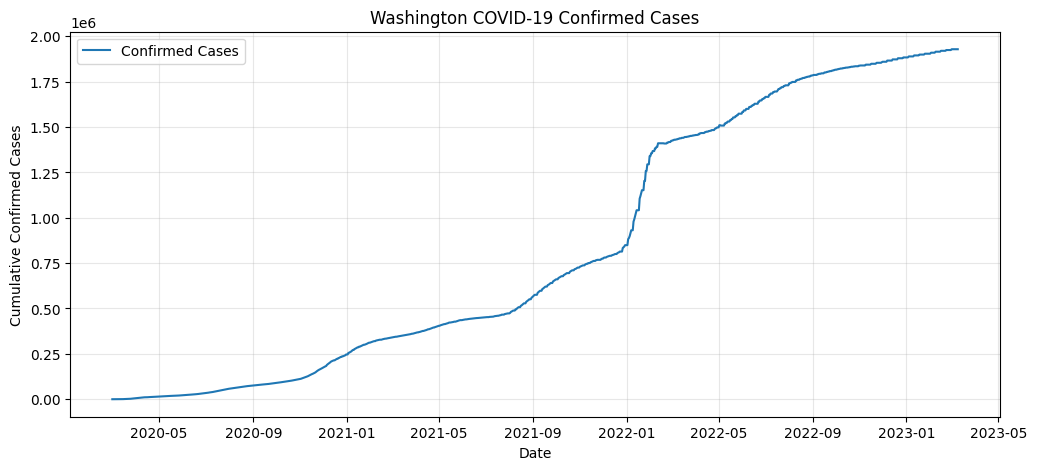

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    washington_df["Date"],
    washington_df["ConfirmedCases"],
    label="Confirmed Cases"
)

plt.title("Washington COVID-19 Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Calculate 10-day and 30-day Simple Moving Averages

A Simple Moving Average replaces each point with the average of a fixed number of recent observations.

I calculate two versions used in the paper:

- **SMA 10:** average of the most recent 10 days
- **SMA 30:** average of the most recent 30 days

A larger window gives a smoother curve but usually reacts more slowly to sudden changes. The initial values are `NaN` because there are not yet enough previous observations to fill the complete moving window.


In [7]:
washington_df["SMA_10"] = (
    washington_df["ConfirmedCases"]
    .rolling(window=10)
    .mean()
)

washington_df["SMA_30"] = (
    washington_df["ConfirmedCases"]
    .rolling(window=30)
    .mean()
)

washington_df[
    ["Date", "ConfirmedCases", "SMA_10", "SMA_30"]
].head(35)


,Date,ConfirmedCases,SMA_10,SMA_30
0,2020-03-01,11,NaN,NaN
1,2020-03-02,18,NaN,NaN
2,2020-03-03,27,NaN,NaN
3,2020-03-04,39,NaN,NaN
4,2020-03-05,70,NaN,NaN
5,2020-03-06,78,NaN,NaN
6,2020-03-07,102,NaN,NaN
7,2020-03-08,122,NaN,NaN
8,2020-03-09,122,NaN,NaN
9,2020-03-10,167,75.6,NaN


## 5. Compare the SMA curves with the actual data

I plot the actual cumulative cases together with the 10-day and 30-day SMA values.

This makes the effect of the window size easy to see: SMA-10 should respond more quickly to changes, while SMA-30 should be smoother and usually show more lag. The graph is the visualization; the SMA values themselves were calculated mathematically in the previous cell.


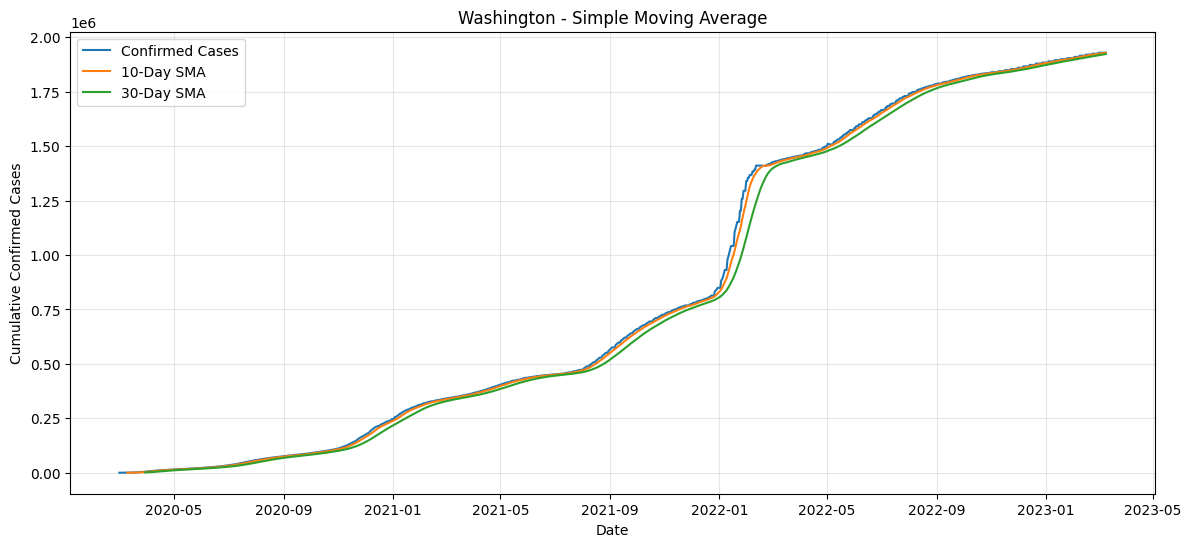

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    washington_df["Date"],
    washington_df["ConfirmedCases"],
    label="Confirmed Cases"
)

plt.plot(
    washington_df["Date"],
    washington_df["SMA_10"],
    label="10-Day SMA"
)

plt.plot(
    washington_df["Date"],
    washington_df["SMA_30"],
    label="30-Day SMA"
)

plt.title("Washington - Simple Moving Average")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


## 6. Calculate the 30-day EWMA

EWMA also smooths the time series, but unlike SMA it does **not give equal importance to every observation**.

With `span=30`, recent observations receive more weight than older observations. `adjust=False` uses the recursive form of EWMA, which is conceptually close to the equation described in the paper.


In [9]:
washington_df["EWMA_30"] = (
    washington_df["ConfirmedCases"]
    .ewm(span=30, adjust=False)
    .mean()
)


## 7. Compare EWMA with the actual cumulative cases

Here I plot the original case counts and the 30-day EWMA on the same graph.

The goal is to see how closely the weighted smoothing curve follows the historical data and whether it reacts to changes faster than a simple moving average.


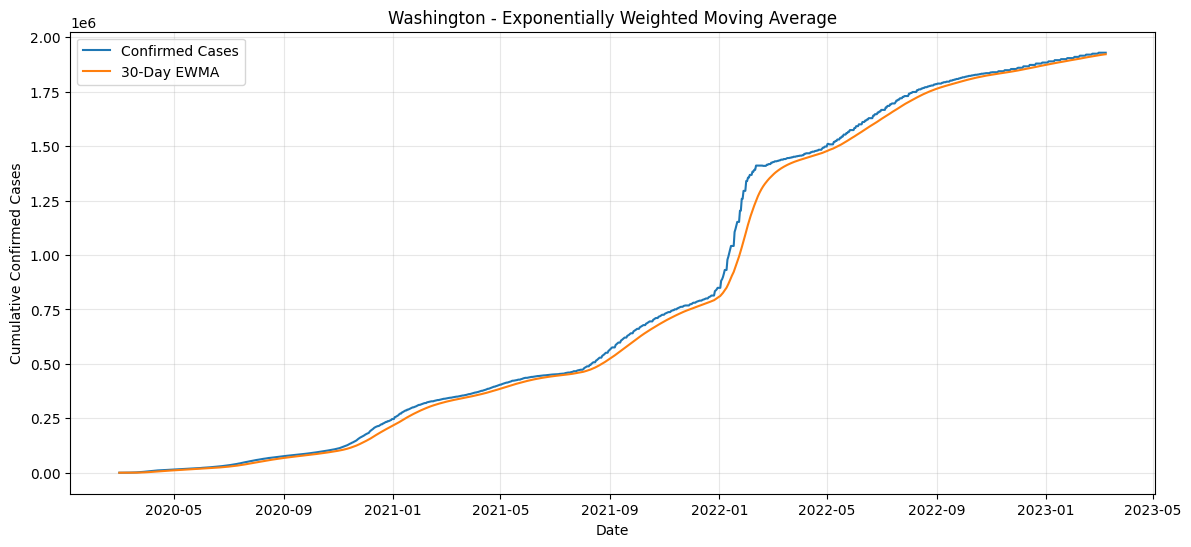

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    washington_df["Date"],
    washington_df["ConfirmedCases"],
    label="Confirmed Cases"
)

plt.plot(
    washington_df["Date"],
    washington_df["EWMA_30"],
    label="30-Day EWMA"
)

plt.title("Washington - Exponentially Weighted Moving Average")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


## 8. Fit the additive Holt-Winters model

Holt-Winters is more flexible than a simple moving average because it can estimate components such as the **level, trend, and seasonality** of a time series.

I use an additive trend and additive seasonality and let `statsmodels` optimize the model parameters. The fitted values are saved as `HW_Additive` so they can be compared with the other methods.

**Reproduction note:** the paper discusses a 30-day span, but it does not clearly report the exact Holt-Winters seasonal-period parameter. Therefore, `seasonal_periods=30` is an implementation assumption in this reproduction rather than a fully documented parameter from the paper.


In [18]:
series = washington_df["ConfirmedCases"].astype(float)

hw_add_model = ExponentialSmoothing(
    series,
    trend="add",
    seasonal="add",
    seasonal_periods=30,
    initialization_method="estimated"
)

hw_add_fit = hw_add_model.fit(
    optimized=True
)

washington_df["HW_Additive"] = hw_add_fit.fittedvalues

print("Additive Holt-Winters fitted successfully.")
print(hw_add_fit.mle_retvals)


Additive Holt-Winters fitted successfully.
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 16091932502.497654
        x: [ 6.425e-01  2.030e-01 ...  5.388e+02  5.362e+01]
      nit: 8
      jac: [-2.312e+06  6.393e+05 ...  2.155e+04 -1.850e+04]
     nfev: 720
     njev: 20
 hess_inv: <35x35 LbfgsInvHessProduct with dtype=float64>


## 9. Inspect the fitted values from all modeling methods

At this point the dataframe contains the actual observations plus the values generated by each modeling method.

I display them together so I can clearly distinguish the original `ConfirmedCases` from the model-generated columns: `SMA_10`, `SMA_30`, `EWMA_30`, and `HW_Additive`.


In [19]:
washington_df[
    [
        "Date",
        "ConfirmedCases",
        "SMA_10",
        "SMA_30",
        "EWMA_30",
        "HW_Additive"
    ]
].head(35)


,Date,ConfirmedCases,SMA_10,SMA_30,EWMA_30,HW_Additive
0,2020-03-01,11,NaN,NaN,11.000000,1429.678178
1,2020-03-02,18,NaN,NaN,11.451613,625.381387
2,2020-03-03,27,NaN,NaN,12.454735,-354.179002
3,2020-03-04,39,NaN,NaN,14.167332,-200.785889
4,2020-03-05,70,NaN,NaN,17.769440,707.025127
5,2020-03-06,78,NaN,NaN,21.655283,-546.489363
6,2020-03-07,102,NaN,NaN,26.838813,1207.159310
7,2020-03-08,122,NaN,NaN,32.978244,-380.716978
8,2020-03-09,122,NaN,NaN,38.721583,732.938233
9,2020-03-10,167,75.6,NaN,46.997610,-357.549668


## 10. Create one common evaluation period

SMA-30 cannot produce values for its first 29 observations, while the other methods can start earlier.

To make the performance comparison fair, I remove rows containing missing model values and evaluate **every method on exactly the same dates**. This prevents one model from receiving an advantage simply because it is evaluated on a different number of observations.


In [20]:
comparison_df = washington_df[
    [
        "Date",
        "ConfirmedCases",
        "SMA_10",
        "SMA_30",
        "EWMA_30",
        "HW_Additive"
    ]
].dropna().copy()

print("Comparison rows:", len(comparison_df))
print("Start date:", comparison_df["Date"].min())
print("End date:", comparison_df["Date"].max())


Comparison rows: 1075
Start date: 2020-03-30 00:00:00
End date: 2023-03-09 00:00:00


## 11. Calculate MSE and RMSE for every model

For each method, I compare the fitted values with the actual cumulative case counts.

- **MSE (Mean Squared Error):** averages the squared prediction errors.
- **RMSE (Root Mean Squared Error):** square root of MSE and is easier to interpret because it is expressed in the same unit as the case counts.

For both metrics, **lower is better**. This gives a numerical comparison instead of relying only on how close the curves look visually.


In [21]:
actual = comparison_df["ConfirmedCases"]

models = {
    "SMA 10": comparison_df["SMA_10"],
    "SMA 30": comparison_df["SMA_30"],
    "EWMA 30": comparison_df["EWMA_30"],
    "Holt-Winters Additive": comparison_df["HW_Additive"]
}

results = []

for model_name, predicted in models.items():

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse
    })


## 12. Rank the models by RMSE

I place the error values in a dataframe and sort the models from smallest to largest RMSE.

The first row therefore represents the method with the closest historical fit over the common comparison period.


In [22]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

results_df


,Model,MSE,RMSE
0,Holt-Winters Additive,1.495733e+07,3867.470742
1,SMA 10,2.103716e+08,14504.191388
2,EWMA 30,1.676451e+09,40944.483262
3,SMA 30,1.922269e+09,43843.684435


## 13. Report the best-performing modeling method

This cell extracts the top-ranked row and prints its model name, RMSE, and MSE.

This gives me a simple final statement for the modeling experiment: the model with the lowest RMSE is the best historical fit among the methods I tested.


In [23]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("RMSE:", best_model["RMSE"])
print("MSE:", best_model["MSE"])


Best Model: Holt-Winters Additive
RMSE: 3867.4707415140697
MSE: 14957329.936467387


## 14. Focused comparison: EWMA vs. additive Holt-Winters

The paper emphasizes the difference between EWMA and Holt-Winters, so I plot those two fitted series with the actual observations.

This graph helps me explain whether Holt-Winters captures changes in the historical cumulative series more closely than EWMA.


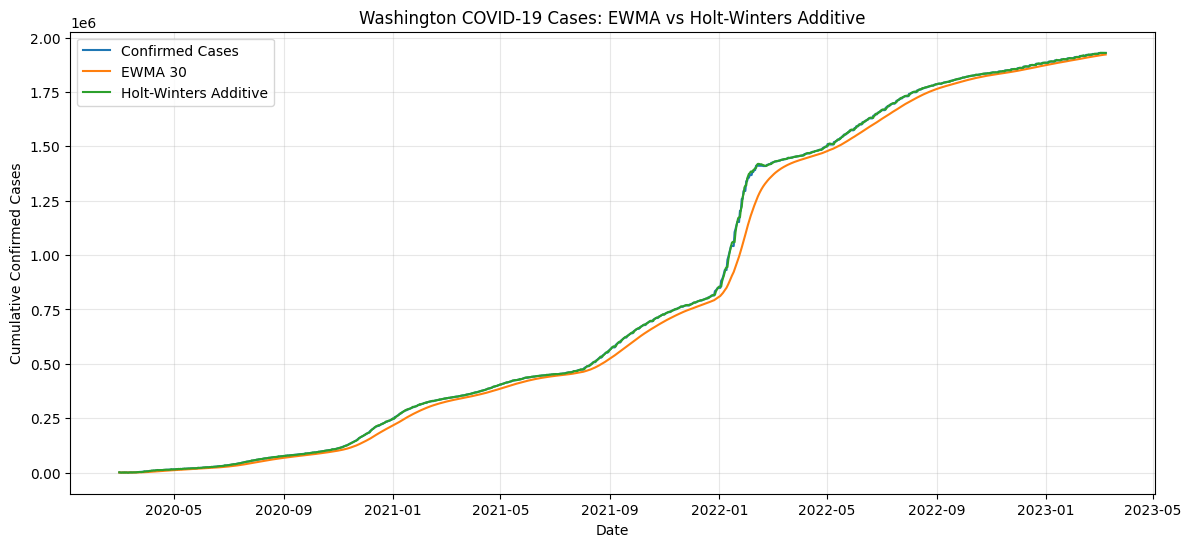

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    washington_df["Date"],
    washington_df["ConfirmedCases"],
    label="Confirmed Cases"
)

plt.plot(
    washington_df["Date"],
    washington_df["EWMA_30"],
    label="EWMA 30"
)

plt.plot(
    washington_df["Date"],
    washington_df["HW_Additive"],
    label="Holt-Winters Additive"
)

plt.title(
    "Washington COVID-19 Cases: EWMA vs Holt-Winters Additive"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


## 15. Final visual comparison of all modeling methods

This final plot overlays the actual Washington cumulative case series with all four fitted model series.

I use this together with the RMSE table: the graph explains **how** the models differ visually, while RMSE provides the quantitative evidence for deciding which method fits the historical data best.


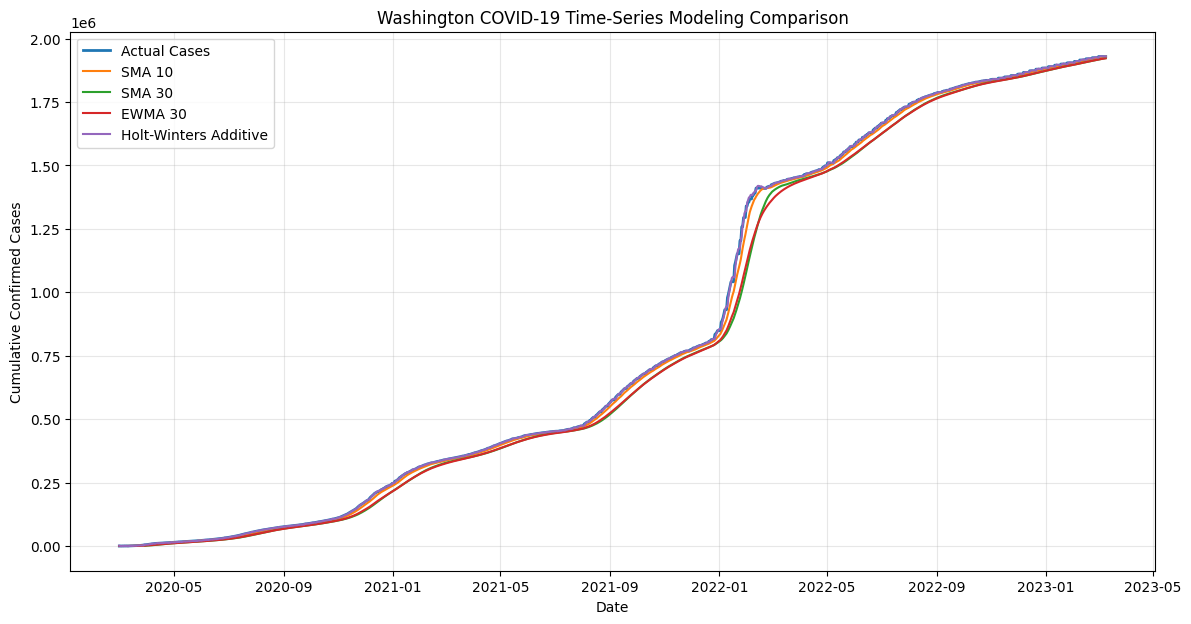

In [25]:
plt.figure(figsize=(14, 7))

plt.plot(
    washington_df["Date"],
    washington_df["ConfirmedCases"],
    label="Actual Cases",
    linewidth=2
)

plt.plot(
    washington_df["Date"],
    washington_df["SMA_10"],
    label="SMA 10"
)

plt.plot(
    washington_df["Date"],
    washington_df["SMA_30"],
    label="SMA 30"
)

plt.plot(
    washington_df["Date"],
    washington_df["EWMA_30"],
    label="EWMA 30"
)

plt.plot(
    washington_df["Date"],
    washington_df["HW_Additive"],
    label="Holt-Winters Additive"
)

plt.title(
    "Washington COVID-19 Time-Series Modeling Comparison"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")

plt.legend()
plt.grid(alpha=0.3)

plt.show()
